# SHAP Model Explainability

This explains the predictions made by the final Logistic Regression model and identifies the key factors influencing customer churn.

In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/saved_model/logistic_regression_model.pkl")

In [3]:
# feature-engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

In [4]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1


In [5]:
df.shape

(7032, 31)

In [7]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
X.shape, y.shape

((7032, 30), (7032,))

Separated the input features and target variable so that SHAP can explain predictions based on customer attributes.

In [9]:
type(model)

sklearn.linear_model._logistic.LogisticRegression

## SHAP Explainer

In [10]:
explainer = shap.Explainer(model, X)

Generated SHAP values to measure how each feature increases or decreases the predicted churn probability.

In [12]:
shap_values = explainer(X)

In [13]:
shap_values

.values =
array([[ 0.0059632 , -0.01415838, -0.00670587, ..., -0.00382531,
         0.12158675, -0.00434097],
       [-0.00572935, -0.01415838,  0.00619003, ..., -0.00382531,
        -0.05988601,  0.02905113],
       [-0.00572935, -0.01415838,  0.00619003, ..., -0.00382531,
        -0.05988601,  0.02905113],
       ...,
       [ 0.0059632 , -0.01415838, -0.00670587, ..., -0.00382531,
         0.12158675, -0.00434097],
       [-0.00572935,  0.05663352, -0.00670587, ..., -0.00382531,
        -0.05988601,  0.02905113],
       [-0.00572935, -0.01415838,  0.00619003, ..., -0.00382531,
        -0.05988601, -0.00434097]], shape=(7032, 30))

.base_values =
array([1419.43104322, 1419.43104322, 1419.43104322, ..., 1419.43104322,
       1419.43104322, 1419.43104322], shape=(7032,))

.data =
array([[1., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 0., 1.],
       

#### *Observation*

*SHAP values were successfully generated for all 7,032 customers and 30 input features. Positive SHAP values indicate features that push predictions toward churn, while negative values indicate features that reduce churn likelihood. Larger absolute values represent a stronger influence on the model's prediction.*

### SHAP Summary Plot

To identify the most influential features driving customer churn predictions across the entire dataset.

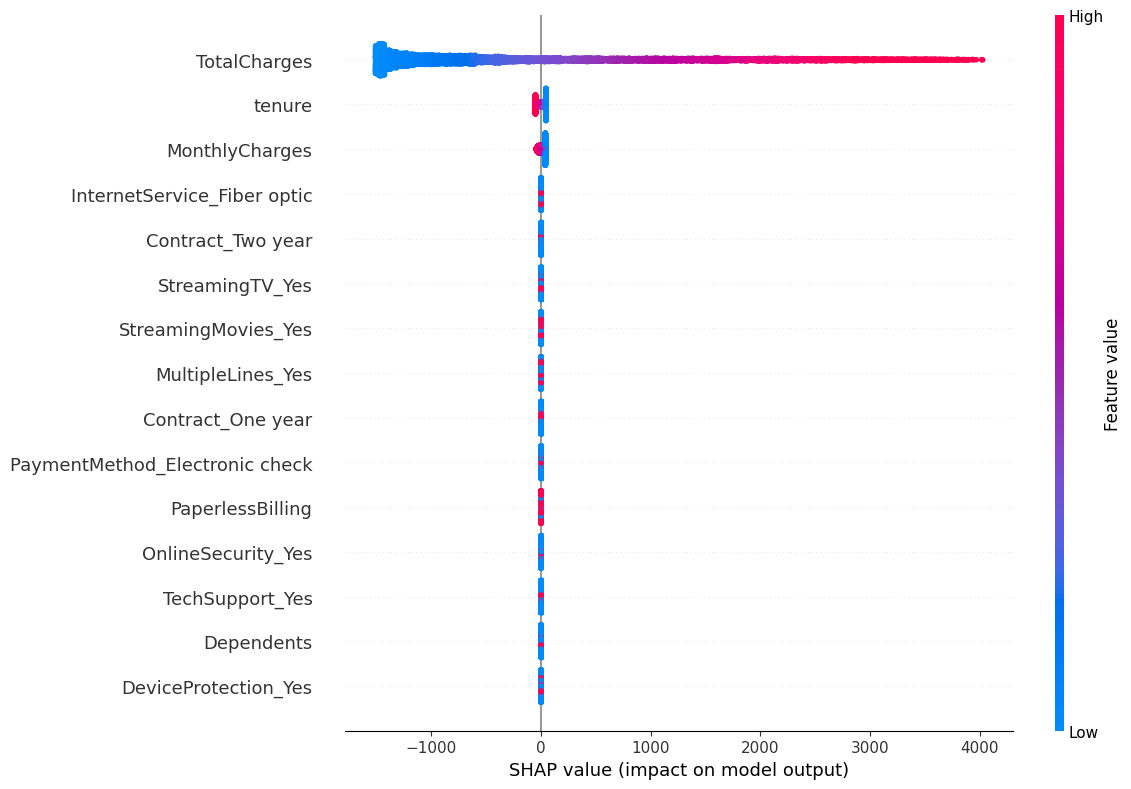

In [15]:
# Beeswarm Plot
shap.summary_plot(
    shap_values,
    X,
    max_display=15,
    plot_size=(12, 8)
)

**Observation:** The SHAP summary plot ranks features based on their influence on churn predictions. TotalCharges, tenure, and MonthlyCharges are the most influential factors. Red points represent high feature values and blue points represent low feature values, while the position along the x-axis indicates whether a feature increases or decreases churn tendency.

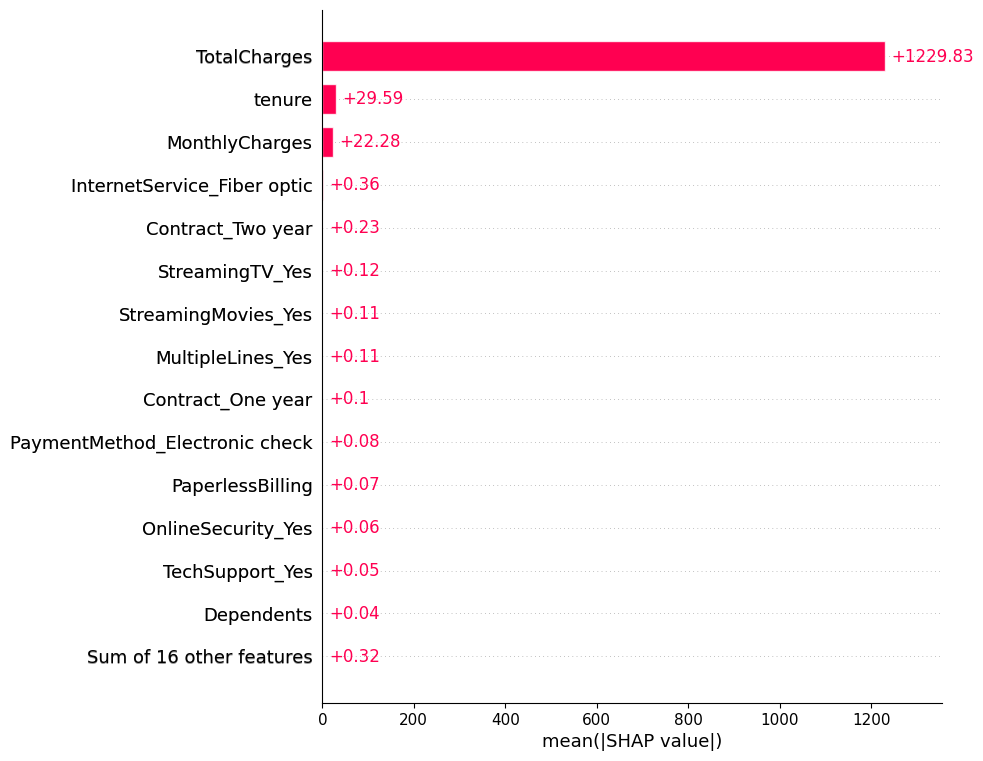

In [16]:
# Bar Plot
shap.plots.bar(shap_values, max_display=15)

**Observation:** The bar plot shows the overall importance of each feature in the model. Features with larger bars have a greater influence on churn predictions and contribute more to the model's decision-making process.

# Key Insights from SHAP Analysis

1. TotalCharges is the most influential feature affecting churn predictions in the model.

2. Tenure and MonthlyCharges are also major drivers of customer churn behaviour.

3. Features related to internet services, contract type, and streaming services have a moderate impact on churn predictions.

4. Positive SHAP values indicate factors that increase the likelihood of churn, whereas negative SHAP values indicate factors that reduce churn likelihood.

5. The model primarily relies on customer spending patterns, subscription duration, and service preferences to distinguish between customers who are likely to churn and those who are likely to remain.

***The SHAP analysis indicates that customer charges, tenure, and service usage patterns are the primary factors influencing churn predictions in the final Logistic Regression model.***